In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Question 10 — Bilateral filtering (`rice.png`)

**(a)** Manual bilateral filter (same math as a literal double loop over the $d\times d$ neighborhood; the inner $d^2$ sum is written with NumPy for speed). Borders: `BORDER_REFLECT_101` padding so OpenCV and manual outputs align more closely at edges.

For grayscale $I$, neighborhood $\Omega$ of diameter $d$ (odd), center $\mathbf{p}$, and neighbor $\mathbf{q}$:

$$\mathrm{BF}[I](\mathbf{p})=\frac{1}{W_{\mathbf{p}}}\sum_{\mathbf{q}\in\Omega}
\exp\!\left(-\frac{\|\mathbf{p}-\mathbf{q}\|^2}{2\sigma_s^2}\right)
\exp\!\left(-\frac{(I(\mathbf{p})-I(\mathbf{q}))^2}{2\sigma_r^2}\right)\,I(\mathbf{q}),$$

$$W_{\mathbf{p}}=\sum_{\mathbf{q}\in\Omega} w(\mathbf{p},\mathbf{q}).$$

**(b)** `cv2.GaussianBlur` — edge-blurring smoothing only. **(c)** `cv2.bilateralFilter`. **(d)** Same parameters for the manual filter from (a).

Max abs difference (manual vs OpenCV bilateral): 7
Mean abs difference: 0.8276


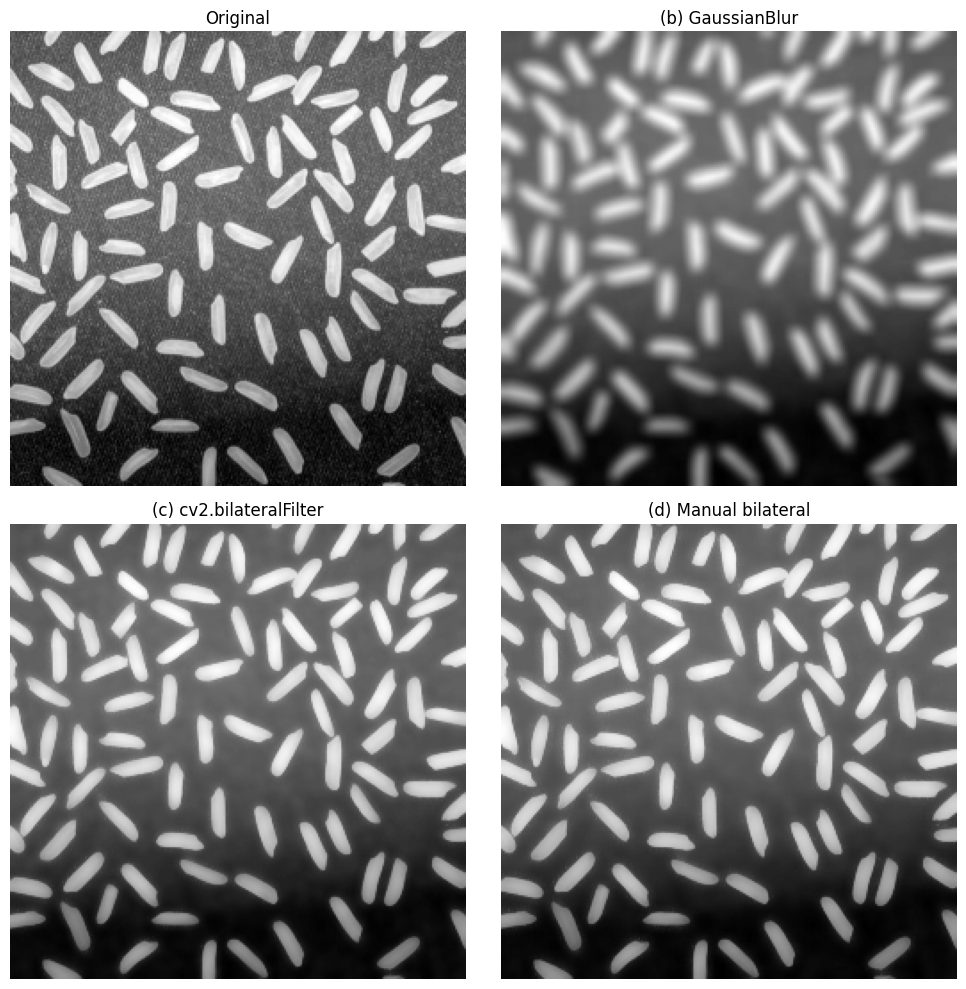

In [2]:
def bilateral_filter_gray(
    gray: np.ndarray,
    d: int,
    sigma_s: float,
    sigma_r: float,
) -> np.ndarray:
    """Manually implement bilateral filter for a single-channel uint8 image.

    Parameters
    ----------
    gray : (H, W) uint8
    d : kernel diameter (odd window size d×d)
    sigma_s : spatial standard deviation (pixels)
    sigma_r : range standard deviation (same units as intensity, 0–255)

    Returns
    -------
    (H, W) uint8
    """
    if gray.ndim != 2:
        raise ValueError("Expected single-channel grayscale image.")
    if gray.dtype != np.uint8:
        raise TypeError("Expected uint8.")
    if d < 1 or d % 2 == 0:
        raise ValueError("Kernel diameter d must be a positive odd integer.")

    img = gray.astype(np.float64)
    h, w = img.shape
    r = d // 2
    out = np.zeros_like(img)

    two_ss = 2.0 * float(sigma_s) * float(sigma_s)
    two_sr = 2.0 * float(sigma_r) * float(sigma_r)

    # Spatial Gaussian on offset grid (same as nested loops, faster)
    ky = np.arange(-r, r + 1, dtype=np.float64)
    kx = np.arange(-r, r + 1, dtype=np.float64)
    Ky, Kx = np.meshgrid(ky, kx, indexing="ij")
    Gs = np.exp(-(Ky * Ky + Kx * Kx) / two_ss)

    pad = cv2.copyMakeBorder(img, r, r, r, r, cv2.BORDER_REFLECT_101)
    for y in range(h):
        for x in range(w):
            patch = pad[y : y + d, x : x + d]
            Ip = img[y, x]
            Gr = np.exp(-((Ip - patch) ** 2) / two_sr)
            W = Gs * Gr
            wsum = float(W.sum())
            out[y, x] = float((W * patch).sum()) / (wsum + 1e-12)

    return np.clip(np.round(out), 0, 255).astype(np.uint8)


path = "images/rice.png"
bgr = cv2.imread(path)
if bgr is None:
    raise FileNotFoundError(path)
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

d = 9
sigma_s = 4.0
sigma_r = 40.0

# (b) Gaussian smoothing (same spatial scale idea; odd ksize = d)
gauss = cv2.GaussianBlur(gray, (d, d), sigma_s)

# (c) OpenCV bilateral (sigmaColor = range, sigmaSpace = spatial)
bilateral_cv = cv2.bilateralFilter(gray, d, sigma_r, sigma_s)

# (d) Manual bilateral
bilateral_man = bilateral_filter_gray(gray, d, sigma_s, sigma_r)

diff = cv2.absdiff(bilateral_man, bilateral_cv)
print(f"Max abs difference (manual vs OpenCV bilateral): {diff.max()}")
print(f"Mean abs difference: {diff.mean():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(gray, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 1].imshow(gauss, cmap="gray")
axes[0, 1].set_title("(b) GaussianBlur")
axes[1, 0].imshow(bilateral_cv, cmap="gray")
axes[1, 0].set_title("(c) cv2.bilateralFilter")
axes[1, 1].imshow(bilateral_man, cmap="gray")
axes[1, 1].set_title("(d) Manual bilateral")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()